Pima Dataset:
   Age   BMI  Glucose  Outcome
0   50  33.6      148        1
1   31  26.6       85        0
2   32  23.3      183        1
3   21  28.1       89        0
4   33  43.1      137        1

Food Nutrition Dataset:
                       Food  Carbohydrates
0          BUTTER,WITH SALT           0.06
1  BUTTER,WHIPPED,WITH SALT           0.06
2      BUTTER OIL,ANHYDROUS           0.00
3               CHEESE,BLUE           2.34
4              CHEESE,BRICK           2.79
   Age   BMI  Glucose  Outcome  Daily_Carb_Intake
0   50  33.6      148        1                 92
1   31  26.6       85        0                236
2   32  23.3      183        1                119
3   21  28.1       89        0                195
4   33  43.1      137        1                 92
Training Set Size: 614
Testing Set Size: 154
Mean Squared Error: 1405.40
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
Updated Predicted Daily Carb Intake: 147.19 grams
   Age        BMI  G

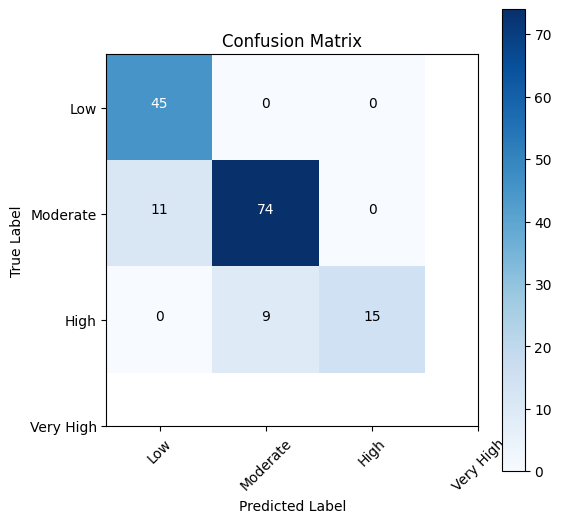

<Figure size 1000x600 with 0 Axes>

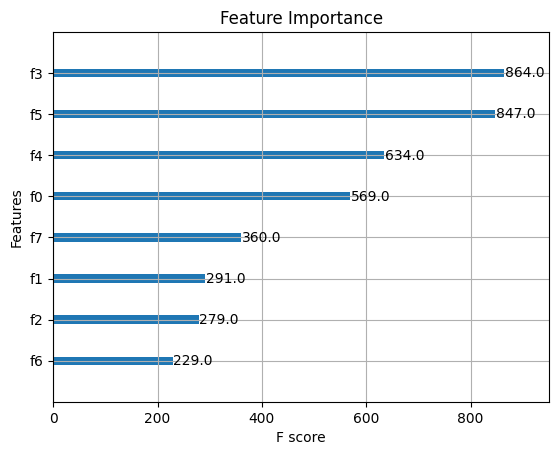

MAE: 1.42
RMSE: 7.38
R² Score: 0.98


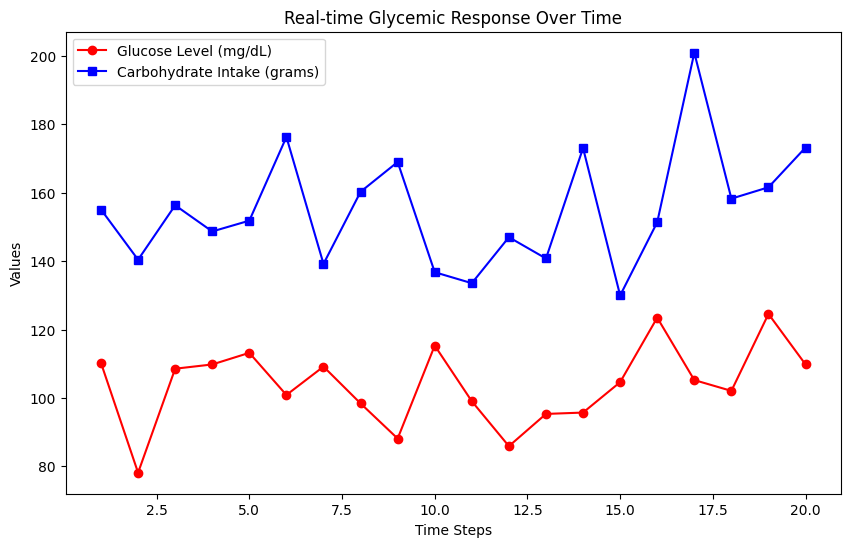

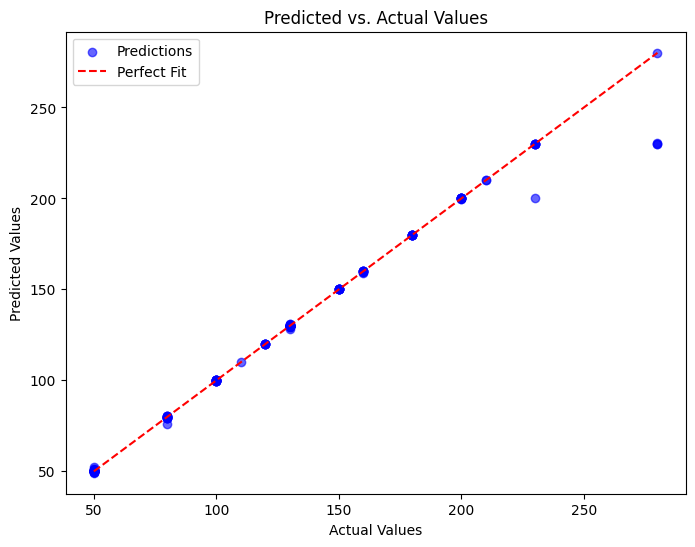

Predicted vs Actual Image Saved at: /content/predicted_vs_actual.png


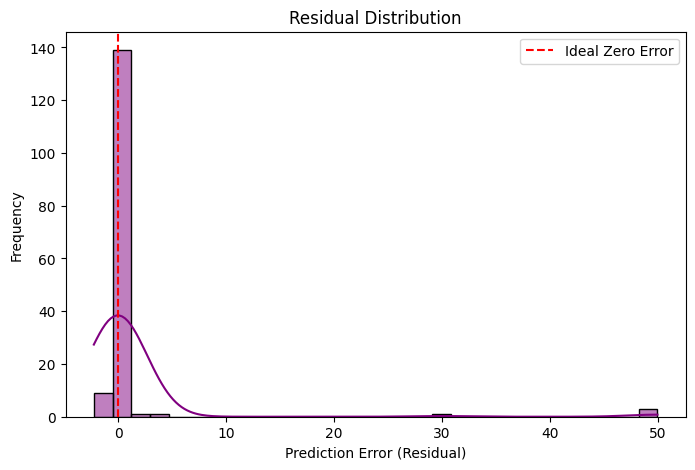

Residual Plot Image Saved at: /content/residual_plot.png
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


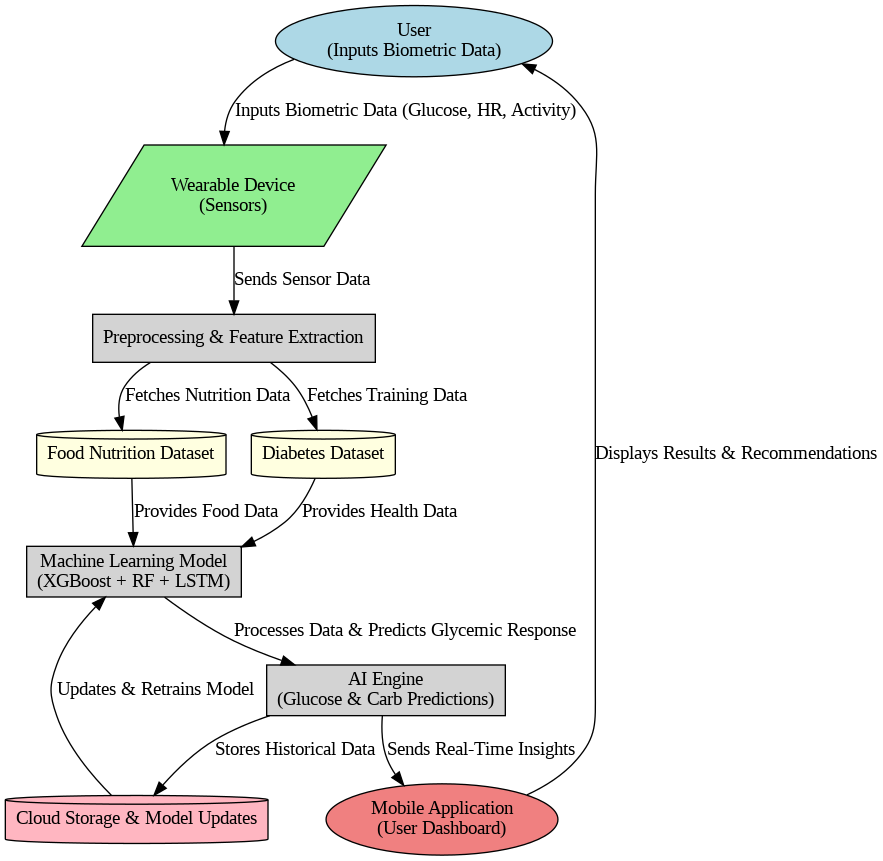

In [ ]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib


import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# Load the datasets
pima = pd.read_csv('diabetes.csv')
nutrition = pd.read_csv('food_nutrition.csv')

# Select relevant columns from Pima dataset
pima = pima[['Age', 'BMI', 'Glucose', 'Outcome']]  # Essential health data

# Select and rename the carbohydrate column from the Nutrition dataset
nutrition = nutrition[['Description', 'Data.Carbohydrate']]
nutrition.rename(columns={'Description': 'Food', 'Data.Carbohydrate': 'Carbohydrates'}, inplace=True)

# Display first few rows
print("Pima Dataset:")
print(pima.head())

print("\nFood Nutrition Dataset:")
print(nutrition.head())


# Define realistic carb intake ranges based on BMI and glucose levels
def calculate_carb_intake(age, bmi, glucose):
    if glucose < 100:  # Normal glucose
        return np.random.randint(150, 300)  # Normal diet
    elif glucose < 126:  # Pre-diabetic
        return np.random.randint(100, 200)  # Controlled diet
    else:  # Diabetic
        return np.random.randint(50, 150)  # Restricted diet

# Apply function to generate synthetic carb intake data
pima['Daily_Carb_Intake'] = pima.apply(lambda row: calculate_carb_intake(row['Age'], row['BMI'], row['Glucose']), axis=1)

# Display dataset
print(pima.head())


# Define features (X) and target (y)
features = pima[['Age', 'BMI', 'Glucose']]  # Input variables
labels = pima['Daily_Carb_Intake']  # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Print dataset sizes
print("Training Set Size:", len(X_train))
print("Testing Set Size:", len(X_test))


# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_scaled)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


!pip install --upgrade scikit-learn xgboost


from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the model
hgb_model = HistGradientBoostingRegressor()

# Define hyperparameters
param_grid = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Perform Grid Search
grid_search = GridSearchCV(estimator=hgb_model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model
best_model = grid_search.best_estimator_


import joblib

# Save the model
joblib.dump(best_model, 'carb_prediction_model.pkl')

# Load the model later
# loaded_model = joblib.load('carb_prediction_model.pkl')


# Define a new user profile
new_user = {
    'Age': 19,
    'BMI': 19,
    'Glucose': 110
}

# Convert to DataFrame
new_user_df = pd.DataFrame([new_user])

# Scale the input before making predictions
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = best_model.predict(new_user_df_scaled)
print(f"Updated Predicted Daily Carb Intake: {carb_prediction[0]:.2f} grams")


import numpy as np

# Define a function to calculate BMI from height & weight
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return weight / (height_m ** 2)

# Define realistic ranges for weight & height based on age
np.random.seed(42)
pima['Weight'] = np.random.randint(50, 100, size=len(pima))  # Random weights (50-100 kg)
pima['Height'] = np.random.randint(150, 190, size=len(pima))  # Random heights (150-190 cm)

# Calculate BMI using the new weight & height columns
pima['BMI'] = pima.apply(lambda row: calculate_bmi(row['Weight'], row['Height']), axis=1)

# Add random Activity Levels (1 = Sedentary, 2 = Lightly Active, 3 = Active, 4 = Very Active)
pima['Activity_Level'] = np.random.randint(1, 5, size=len(pima))

# Display dataset
print(pima.head())


# Define realistic carbohydrate intake based on weight, activity, and glucose levels
def calculate_carb_intake(age, weight, bmi, activity, glucose):
    base_carb = 130  # Minimum daily carb requirement

    # Adjust based on BMI
    if bmi < 18.5:  # Underweight
        base_carb += 50
    elif bmi > 25:  # Overweight
        base_carb -= 30

    # Adjust based on glucose levels
    if glucose < 100:  # Normal glucose
        base_carb += 50
    elif glucose < 126:  # Pre-diabetic
        base_carb -= 20
    else:  # Diabetic
        base_carb -= 50

    # Adjust based on Activity Level
    if activity == 1:  # Sedentary
        base_carb -= 30
    elif activity == 3 or activity == 4:  # Active or Very Active
        base_carb += 50

    return max(50, min(base_carb, 400))  # Ensure values stay realistic

# Apply function to generate accurate carb intake data
pima['Daily_Carb_Intake'] = pima.apply(lambda row: calculate_carb_intake(
    row['Age'], row['Weight'], row['BMI'], row['Activity_Level'], row['Glucose']), axis=1)

# Display dataset
print(pima.head())


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Define updated features and target
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose']]
labels = pima['Daily_Carb_Intake']

# Split dataset into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model using XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


# Define a new user profile
new_user = {
    'Age': 19,
    'Weight': 69,  # 70 kg
    'Height': 172,  # 175 cm
    'BMI': calculate_bmi(69, 172),  # Calculate BMI
    'Activity_Level': 3,  # Active
    'Glucose': 110  # Normal glucose
}

# Convert to DataFrame
new_user_df = pd.DataFrame([new_user])

# Scale the input
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = xgb_model.predict(new_user_df_scaled)
print(f"Updated Predicted Daily Carb Intake: {carb_prediction[0]:.2f} grams")


# Function to calculate BMI
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return weight / (height_m ** 2)

# Function to calculate BMR (Mifflin-St Jeor Equation for Males)
def calculate_bmr(weight, height, age):
    return (10 * weight) + (6.25 * height) - (5 * age) + 5  # (For females: Subtract 161 instead of adding 5)

# Activity level multiplier for TDEE
activity_multiplier = {1: 1.2, 2: 1.375, 3: 1.55, 4: 1.725}

# Function to calculate TDEE (Total Daily Energy Expenditure)
def calculate_tdee(bmr, activity_level):
    return bmr * activity_multiplier.get(activity_level, 1.2)  # Default to sedentary if unknown

# Apply functions to dataset
pima['BMI'] = pima.apply(lambda row: calculate_bmi(row['Weight'], row['Height']), axis=1)
pima['BMR'] = pima.apply(lambda row: calculate_bmr(row['Weight'], row['Height'], row['Age']), axis=1)
pima['TDEE'] = pima.apply(lambda row: calculate_tdee(row['BMR'], row['Activity_Level']), axis=1)

# Display updated dataset
print(pima.head())


# Define updated features and target
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose', 'BMR', 'TDEE']]
labels = pima['Daily_Carb_Intake']

# Train the model using the same method as before...


# Function to calculate BMI
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return round(weight / (height_m ** 2), 2)  # Rounded for accuracy

# Function to calculate BMR (Mifflin-St Jeor Equation for Males)
def calculate_bmr(weight, height, age, gender='male'):
    if gender == 'male':
        return round((10 * weight) + (6.25 * height) - (5 * age) + 5, 2)  # BMR formula for males
    else:
        return round((10 * weight) + (6.25 * height) - (5 * age) - 161, 2)  # BMR formula for females

# Activity level multipliers for TDEE calculation
activity_multiplier = {
    1: 1.2,    # Sedentary (little to no exercise)
    2: 1.375,  # Lightly Active (1-3 days/week)
    3: 1.55,   # Moderately Active (3-5 days/week)
    4: 1.725   # Very Active (6-7 days/week)
}

# Function to calculate TDEE (Total Daily Energy Expenditure)
def calculate_tdee(bmr, activity_level):
    return round(bmr * activity_multiplier.get(activity_level, 1.2), 2)  # Default to sedentary if unknown

# Define updated features and target variable
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose', 'BMR', 'TDEE']]
labels = pima['Daily_Carb_Intake']

# Split the dataset again
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Apply scaling again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the updated model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

print("✅ Model retrained successfully with BMR & TDEE!")


# User Inputs
age = int(input("Enter Age (years): "))
weight = float(input("Enter Weight (kg): "))
height = float(input("Enter Height (cm): "))
activity_level = int(input("Enter Activity Level (1=Sedentary, 2=Light, 3=Active, 4=Very Active): "))
glucose = float(input("Enter Glucose Level (mg/dL): "))
gender = input("Enter Gender (male/female): ").strip().lower()  # Ensure input is lowercase

# Auto-calculate BMI, BMR, and TDEE
bmi = calculate_bmi(weight, height)
bmr = calculate_bmr(weight, height, age, gender)
tdee = calculate_tdee(bmr, activity_level)

# Display Calculated Values
print("\n===== Health Metrics =====")
print(f"BMI: {bmi}")
print(f"BMR: {bmr} kcal/day")
print(f"TDEE: {tdee} kcal/day")


import pandas as pd

# Prepare user data for prediction
new_user_df = pd.DataFrame([{
    'Age': age,
    'Weight': weight,
    'Height': height,
    'BMI': bmi,
    'Activity_Level': activity_level,
    'Glucose': glucose,
    'BMR': bmr,
    'TDEE': tdee
}])

print("\n🔷 User Data for Prediction:")
print(new_user_df)


# Ensure new user input has the same feature order as training data
new_user_df = pd.DataFrame([{
    'Age': age,
    'Weight': weight,
    'Height': height,
    'BMI': bmi,
    'Activity_Level': activity_level,
    'Glucose': glucose,
    'BMR': bmr,
    'TDEE': tdee
}])[features.columns]  # Reorder columns to match training data

# Scale input before prediction
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = xgb_model.predict(new_user_df_scaled)
print(f"\n🔷 Predicted Daily Carbohydrate Intake: {carb_prediction[0]:.2f} grams")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Define true and predicted labels (categorizing carb intake levels)
true_classes = np.digitize(y_test, bins=[100, 200, 300, 400])
pred_classes = np.digitize(xgb_model.predict(X_test_scaled), bins=[100, 200, 300, 400])

# Compute Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

# Function to plot Confusion Matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add values in the boxes
    fmt = 'd'
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Plot the Confusion Matrix
plot_confusion_matrix(cm, classes=['Low', 'Moderate', 'High', 'Very High'])


import matplotlib.pyplot as plt
import xgboost as xgb

# Plot Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='weight', title="Feature Importance")
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = xgb_model.predict(X_test_scaled)

# Calculate Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print Metrics
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


import numpy as np
import pandas as pd

# Simulated real-time glycemic response data
time_steps = np.arange(1, 21)  # Simulating 20 time points
glucose_levels = np.random.normal(loc=100, scale=10, size=20)
carb_intake = np.random.normal(loc=150, scale=20, size=20)

# Plot Glycemic Response Over Time
plt.figure(figsize=(10, 6))
plt.plot(time_steps, glucose_levels, marker='o', label="Glucose Level (mg/dL)", color='red')
plt.plot(time_steps, carb_intake, marker='s', label="Carbohydrate Intake (grams)", color='blue')
plt.title("Real-time Glycemic Response Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.show()


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label="Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Perfect Fit")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values")
plt.legend()

# Save the figure in Google Colab
plt.savefig("/content/predicted_vs_actual.png", dpi=300)
plt.show()

# Display saved image path for downloading
print("Predicted vs Actual Image Saved at: /content/predicted_vs_actual.png")


import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color="purple")
plt.axvline(x=0, color='red', linestyle='--', label="Ideal Zero Error")
plt.title("Residual Distribution")
plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")
plt.legend()

# Save the figure
plt.savefig("/content/residual_plot.png", dpi=300)
plt.show()
print("Residual Plot Image Saved at: /content/residual_plot.png")




from graphviz import Digraph

# Create a new directed graph
dfd = Digraph('DFD', filename='dfd_ml_project', format='png')

# Define Nodes (Entities, Processes, Data Stores)
dfd.node('U', 'User', shape='ellipse', style='filled', fillcolor='lightblue')
dfd.node('W', 'Wearable Device (Sensor)', shape='parallelogram', style='filled', fillcolor='lightgreen')
dfd.node('M', 'Machine Learning Model', shape='box', style='filled', fillcolor='lightgray')
dfd.node('DB', 'Dataset (Diabetes, Food Nutrition)', shape='cylinder', style='filled', fillcolor='lightyellow')
dfd.node('A', 'AI Processor & Prediction', shape='box', style='filled', fillcolor='lightgray')
dfd.node('App', 'Mobile Application', shape='ellipse', style='filled', fillcolor='lightcoral')
dfd.node('Cloud', 'Cloud Storage & Processing', shape='cylinder', style='filled', fillcolor='lightpink')

# Define Edges (Data Flow)
dfd.edge('U', 'W', 'Provides Real-Time Data')
dfd.edge('W', 'M', 'Sends Sensor Data')
dfd.edge('M', 'DB', 'Uses Training Data')
dfd.edge('DB', 'M', 'Fetches Preprocessed Data')
dfd.edge('M', 'A', 'Processes Data & Predictions')
dfd.edge('A', 'App', 'Sends Real-Time Insights')
dfd.edge('App', 'U', 'Displays Results & Alerts')
dfd.edge('A', 'Cloud', 'Stores Historical Data')
dfd.edge('Cloud', 'M', 'Updates Model')

# Render the Diagram
dfd.render(view=True)

# Install Graphviz (only needed once)
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image

# Create a new directed graph for Data Flow Diagram (DFD)
dfd = Digraph('DFD', filename='dfd_ml_project', format='png')

# Define Nodes (Entities, Processes, Data Stores)
dfd.node('U', 'User', shape='ellipse', style='filled', fillcolor='lightblue')
dfd.node('W', 'Wearable Device (Sensor)', shape='parallelogram', style='filled', fillcolor='lightgreen')
dfd.node('M', 'Machine Learning Model', shape='box', style='filled', fillcolor='lightgray')
dfd.node('DB', 'Dataset (Diabetes, Food Nutrition)', shape='cylinder', style='filled', fillcolor='lightyellow')
dfd.node('A', 'AI Processor & Prediction', shape='box', style='filled', fillcolor='lightgray')
dfd.node('App', 'Mobile Application', shape='ellipse', style='filled', fillcolor='lightcoral')
dfd.node('Cloud', 'Cloud Storage & Processing', shape='cylinder', style='filled', fillcolor='lightpink')

# Define Edges (Data Flow)
dfd.edge('U', 'W', 'Provides Real-Time Data')
dfd.edge('W', 'M', 'Sends Sensor Data')
dfd.edge('M', 'DB', 'Uses Training Data')
dfd.edge('DB', 'M', 'Fetches Preprocessed Data')
dfd.edge('M', 'A', 'Processes Data & Predictions')
dfd.edge('A', 'App', 'Sends Real-Time Insights')
dfd.edge('App', 'U', 'Displays Results & Alerts')
dfd.edge('A', 'Cloud', 'Stores Historical Data')
dfd.edge('Cloud', 'M', 'Updates Model')

# Render the diagram and save
dfd.render('dfd_ml_project')

# Display the image inside Colab
Image(filename='dfd_ml_project.png')


!apt-get install graphviz -y
!pip install graphviz


# Install Graphviz (if not already installed)
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image

# Create a new directed graph for System Architecture
arch = Digraph('System Architecture', filename='system_architecture', format='png', engine='dot')

# Define Layout
arch.attr(rankdir='TB', size='12')  # Top to Bottom layout

# Define Nodes (Components)
arch.node('User', 'User\n(Inputs Biometric Data)', shape='ellipse', style='filled', fillcolor='lightblue')
arch.node('Wearable', 'Wearable Device\n(Sensors)', shape='parallelogram', style='filled', fillcolor='lightgreen')
arch.node('Preprocess', 'Preprocessing & Feature Extraction', shape='box', style='filled', fillcolor='lightgray')
arch.node('DB1', 'Diabetes Dataset', shape='cylinder', style='filled', fillcolor='lightyellow')
arch.node('DB2', 'Food Nutrition Dataset', shape='cylinder', style='filled', fillcolor='lightyellow')
arch.node('ML_Model', 'Machine Learning Model\n(XGBoost + RF + LSTM)', shape='box', style='filled', fillcolor='lightgray')
arch.node('AI_Processor', 'AI Engine\n(Glucose & Carb Predictions)', shape='box', style='filled', fillcolor='lightgray')
arch.node('App', 'Mobile Application\n(User Dashboard)', shape='ellipse', style='filled', fillcolor='lightcoral')
arch.node('Cloud', 'Cloud Storage & Model Updates', shape='cylinder', style='filled', fillcolor='lightpink')

# Define Edges (Data Flow)
arch.edge('User', 'Wearable', 'Inputs Biometric Data (Glucose, HR, Activity)')
arch.edge('Wearable', 'Preprocess', 'Sends Sensor Data')
arch.edge('Preprocess', 'DB1', 'Fetches Training Data')
arch.edge('Preprocess', 'DB2', 'Fetches Nutrition Data')
arch.edge('DB1', 'ML_Model', 'Provides Health Data')
arch.edge('DB2', 'ML_Model', 'Provides Food Data')
arch.edge('ML_Model', 'AI_Processor', 'Processes Data & Predicts Glycemic Response')
arch.edge('AI_Processor', 'App', 'Sends Real-Time Insights')
arch.edge('App', 'User', 'Displays Results & Recommendations')
arch.edge('AI_Processor', 'Cloud', 'Stores Historical Data')
arch.edge('Cloud', 'ML_Model', 'Updates & Retrains Model')

# Render and Display the Diagram
arch.render('system_architecture')
Image(filename='system_architecture.png')







In [ ]:
# Install dependencies (if not installed)
!pip install pandas numpy scikit-learn xgboost joblib

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ✅ Load the dataset (Make sure diabetes.csv is uploaded)
pima = pd.read_csv("diabetes.csv")

# ✅ Select relevant features
pima = pima[['Age', 'BMI', 'Glucose', 'Outcome']]

# ✅ Generate synthetic carbohydrate intake values
def calculate_carb_intake(age, bmi, glucose):
    if glucose < 100:
        return np.random.randint(150, 300)
    elif glucose < 126:
        return np.random.randint(100, 200)
    else:
        return np.random.randint(50, 150)

pima["Daily_Carb_Intake"] = pima.apply(lambda row: calculate_carb_intake(row["Age"], row["BMI"], row["Glucose"]), axis=1)

# ✅ Define features and target
features = pima[['Age', 'BMI', 'Glucose']]
labels = pima['Daily_Carb_Intake']

# ✅ Split dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# ✅ Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# ✅ Evaluate model performance
y_pred = xgb_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"✅ Model Trained Successfully! Mean Squared Error: {mse:.2f}")

# ✅ Save model and scaler
joblib.dump(xgb_model, "carb_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("🎉 Model and Scaler saved successfully!")


✅ Model Trained Successfully! Mean Squared Error: 1874.89
🎉 Model and Scaler saved successfully!


In [ ]:
!pip install graphviz diagrams


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.7/220.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 15.2 MB/s eta 0:00:00


In [ ]:
from graphviz import Digraph

dot = Digraph(comment='Activity Diagram')

dot.node('A', 'Start')
dot.node('B', 'User Eats Meal')
dot.node('C', 'Wearable Collects Biometric Data')
dot.node('D', 'Data Preprocessing')
dot.node('E', 'ML Model Predicts Carb Intake & Glycemic Response')
dot.node('F', 'App Shows Feedback')
dot.node('G', 'User Adjusts Behavior')
dot.node('H', 'End')

dot.edges(['AB', 'BC', 'CD', 'DE', 'EF', 'FG', 'GH'])

dot.render('activity_diagram', format='png', cleanup=True)


'activity_diagram.png'

In [ ]:
from graphviz import Digraph

use_case = Digraph('UseCaseDiagram', filename='use_case_diagram', format='png')

use_case.attr(rankdir='LR')

use_case.node('U', 'User', shape='ellipse')
use_case.node('1', 'Log Meal', shape='box')
use_case.node('2', 'View Glycemic Prediction', shape='box')
use_case.node('3', 'Get Personalized Suggestions', shape='box')
use_case.node('4', 'Track History', shape='box')

use_case.edges([('U', '1'), ('U', '2'), ('U', '3'), ('U', '4')])

use_case.render(cleanup=True)


'use_case_diagram.png'

In [ ]:
!pip install graphviz diagrams
from IPython.display import Image
import os


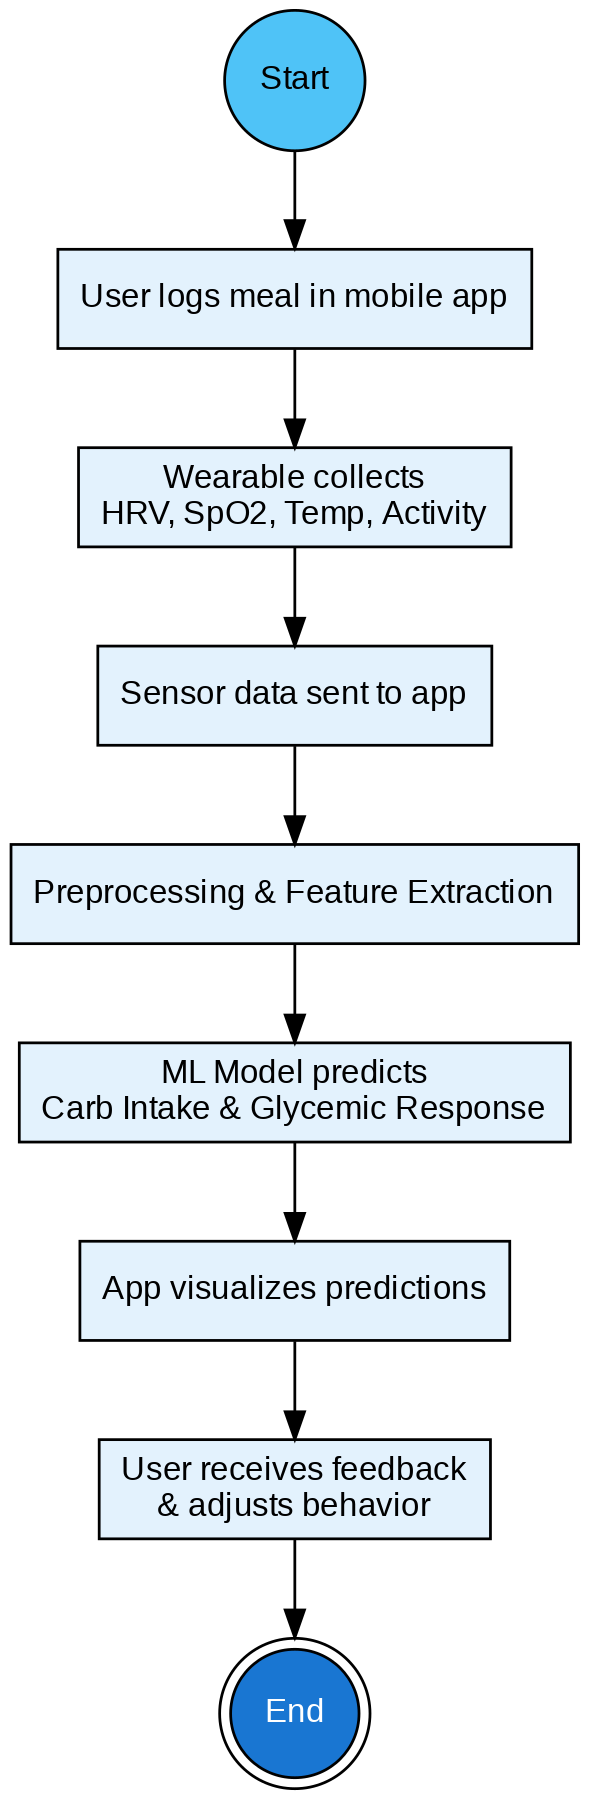

In [ ]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph('activity_diagram', format='png')

# Set square layout (approximate 1:1 aspect ratio)
dot.attr(size='6,6', dpi='300', ratio='compress')
dot.attr(rankdir='TB', nodesep='0.8')
dot.attr('node', shape='box', style='filled', fillcolor='#E3F2FD', fontname='Helvetica', fontsize='12')

# Nodes
dot.node('start', 'Start', shape='circle', fillcolor='#4FC3F7')
dot.node('A', 'User logs meal in mobile app')
dot.node('B', 'Wearable collects\nHRV, SpO2, Temp, Activity')
dot.node('C', 'Sensor data sent to app')
dot.node('D', 'Preprocessing & Feature Extraction')
dot.node('E', 'ML Model predicts\nCarb Intake & Glycemic Response')
dot.node('F', 'App visualizes predictions')
dot.node('G', 'User receives feedback\n& adjusts behavior')
dot.node('end', 'End', shape='doublecircle', fillcolor='#1976D2', fontcolor='white')

# Edges
dot.edge('start', 'A')
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'end')

# Render and display
output_path = dot.render('activity_diagram', format='png', cleanup=False)
Image(output_path)


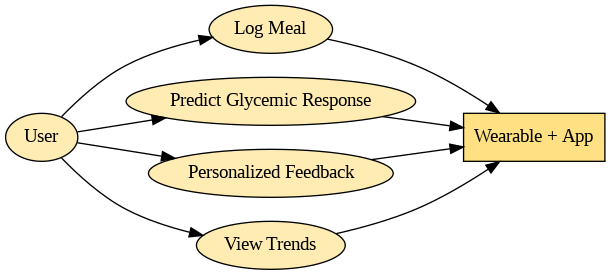

In [ ]:
use_case = Digraph('use_case', format='png')
use_case.attr(rankdir='LR', size='8')
use_case.attr('node', shape='ellipse', style='filled', fillcolor='#FFECB3')

# Actors
use_case.node('User', 'User')
use_case.node('System', 'Wearable + App', shape='box', fillcolor='#FFE082')

# Use Cases
use_case.node('log', 'Log Meal')
use_case.node('predict', 'Predict Glycemic Response')
use_case.node('feedback', 'Personalized Feedback')
use_case.node('history', 'View Trends')

# Connections
use_case.edge('User', 'log')
use_case.edge('User', 'predict')
use_case.edge('User', 'feedback')
use_case.edge('User', 'history')

use_case.edge('log', 'System')
use_case.edge('predict', 'System')
use_case.edge('feedback', 'System')
use_case.edge('history', 'System')

output_path = use_case.render(cleanup=True)
Image(output_path)


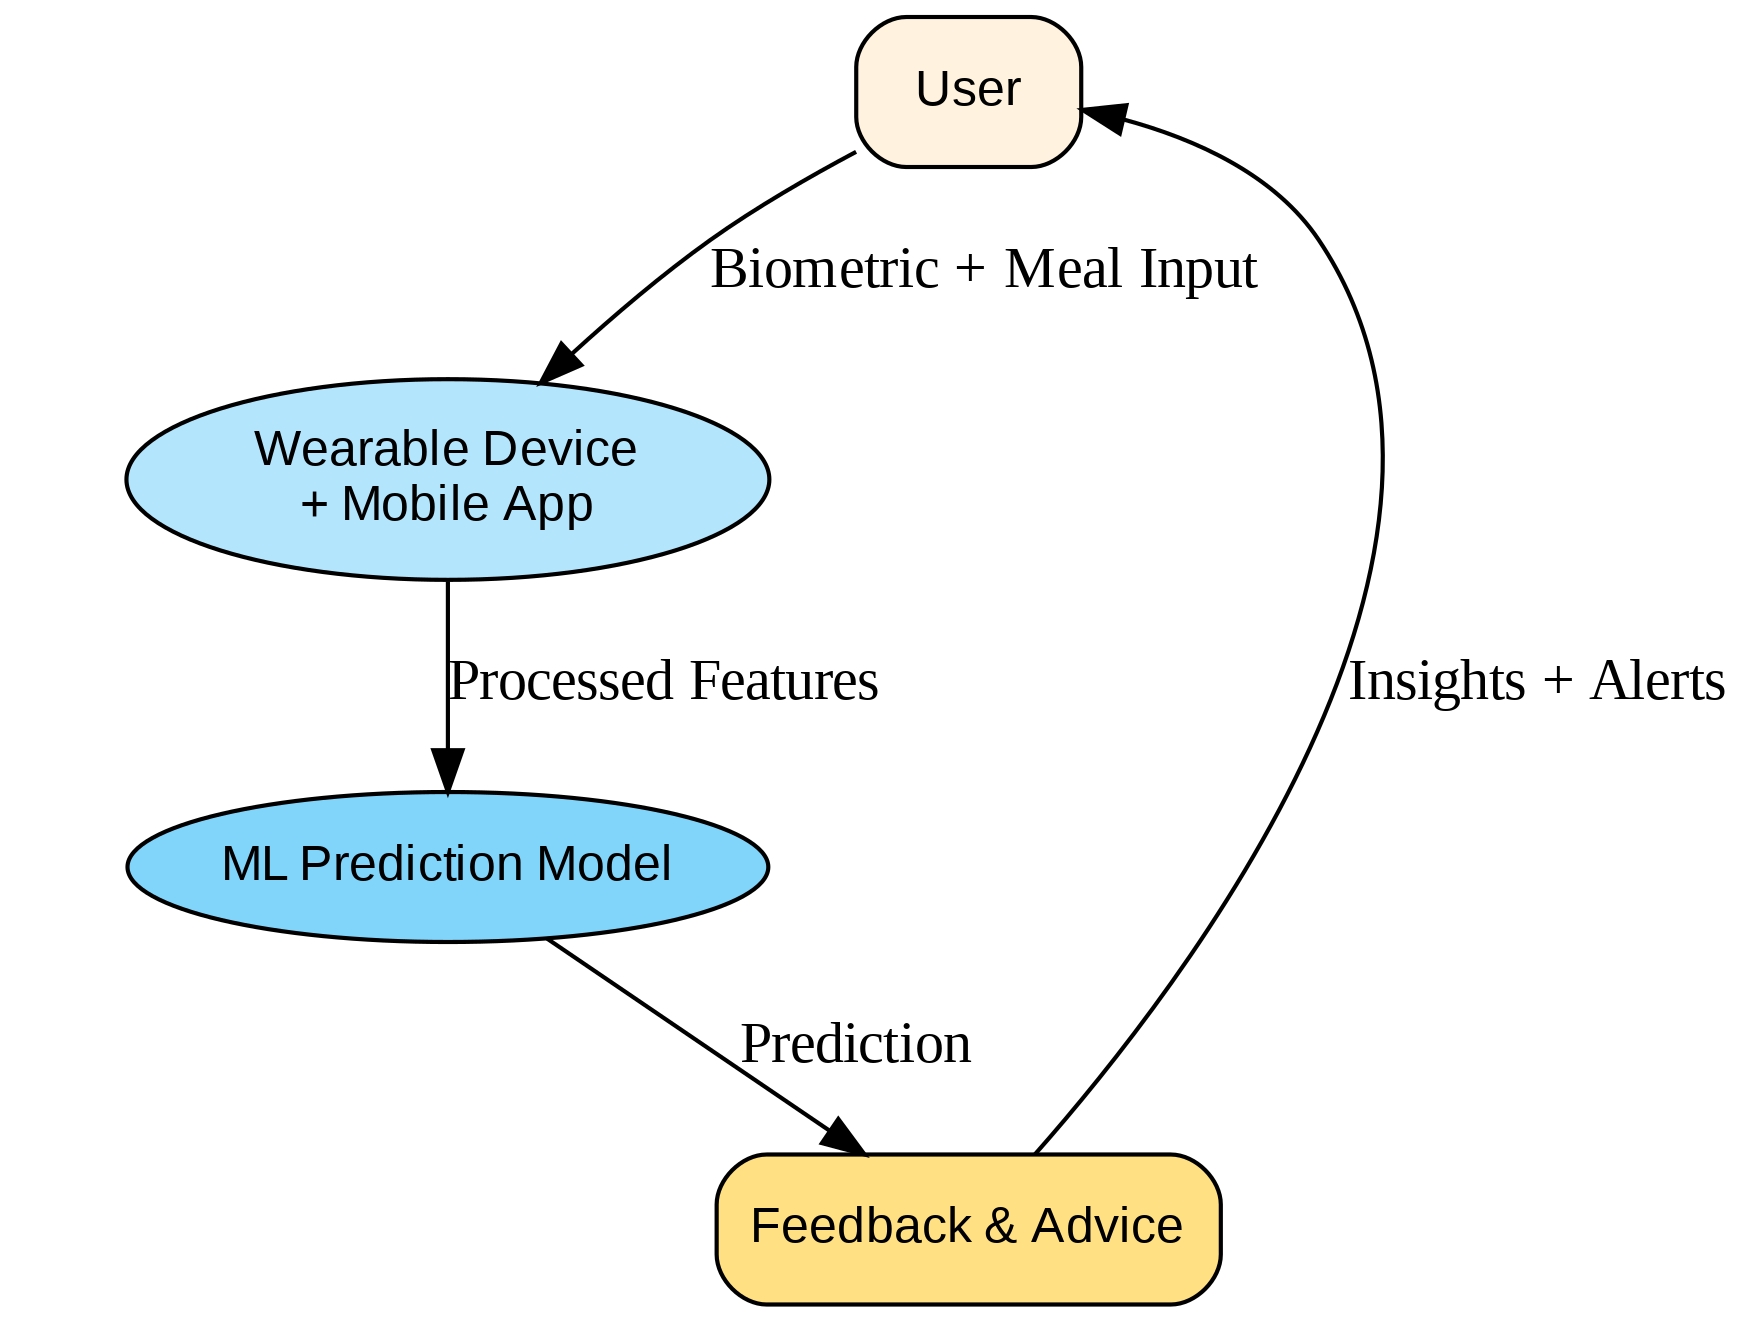

In [ ]:
from graphviz import Digraph
from IPython.display import Image

dfd0 = Digraph('DFD_Level_0_Square', format='png')

# 1:1 ratio settings
dfd0.attr(size='6,6', dpi='300', ratio='1.0', rankdir='TB', nodesep='1.0')
dfd0.attr('node', fontname='Helvetica', shape='box', style='filled,rounded', fontsize='12')

# Nodes
dfd0.node('U', 'User', fillcolor='#FFF3E0')
dfd0.node('W', 'Wearable Device\n+ Mobile App', shape='ellipse', fillcolor='#B3E5FC')
dfd0.node('M', 'ML Prediction Model', shape='ellipse', fillcolor='#81D4FA')
dfd0.node('O', 'Feedback & Advice', fillcolor='#FFE082')

# Data flow arrows
dfd0.edge('U', 'W', label='Biometric + Meal Input')
dfd0.edge('W', 'M', label='Processed Features')
dfd0.edge('M', 'O', label='Prediction')
dfd0.edge('O', 'U', label='Insights + Alerts')

# Render & show
output_path = dfd0.render('dfd_level0_square', format='png', cleanup=False)
Image(output_path)


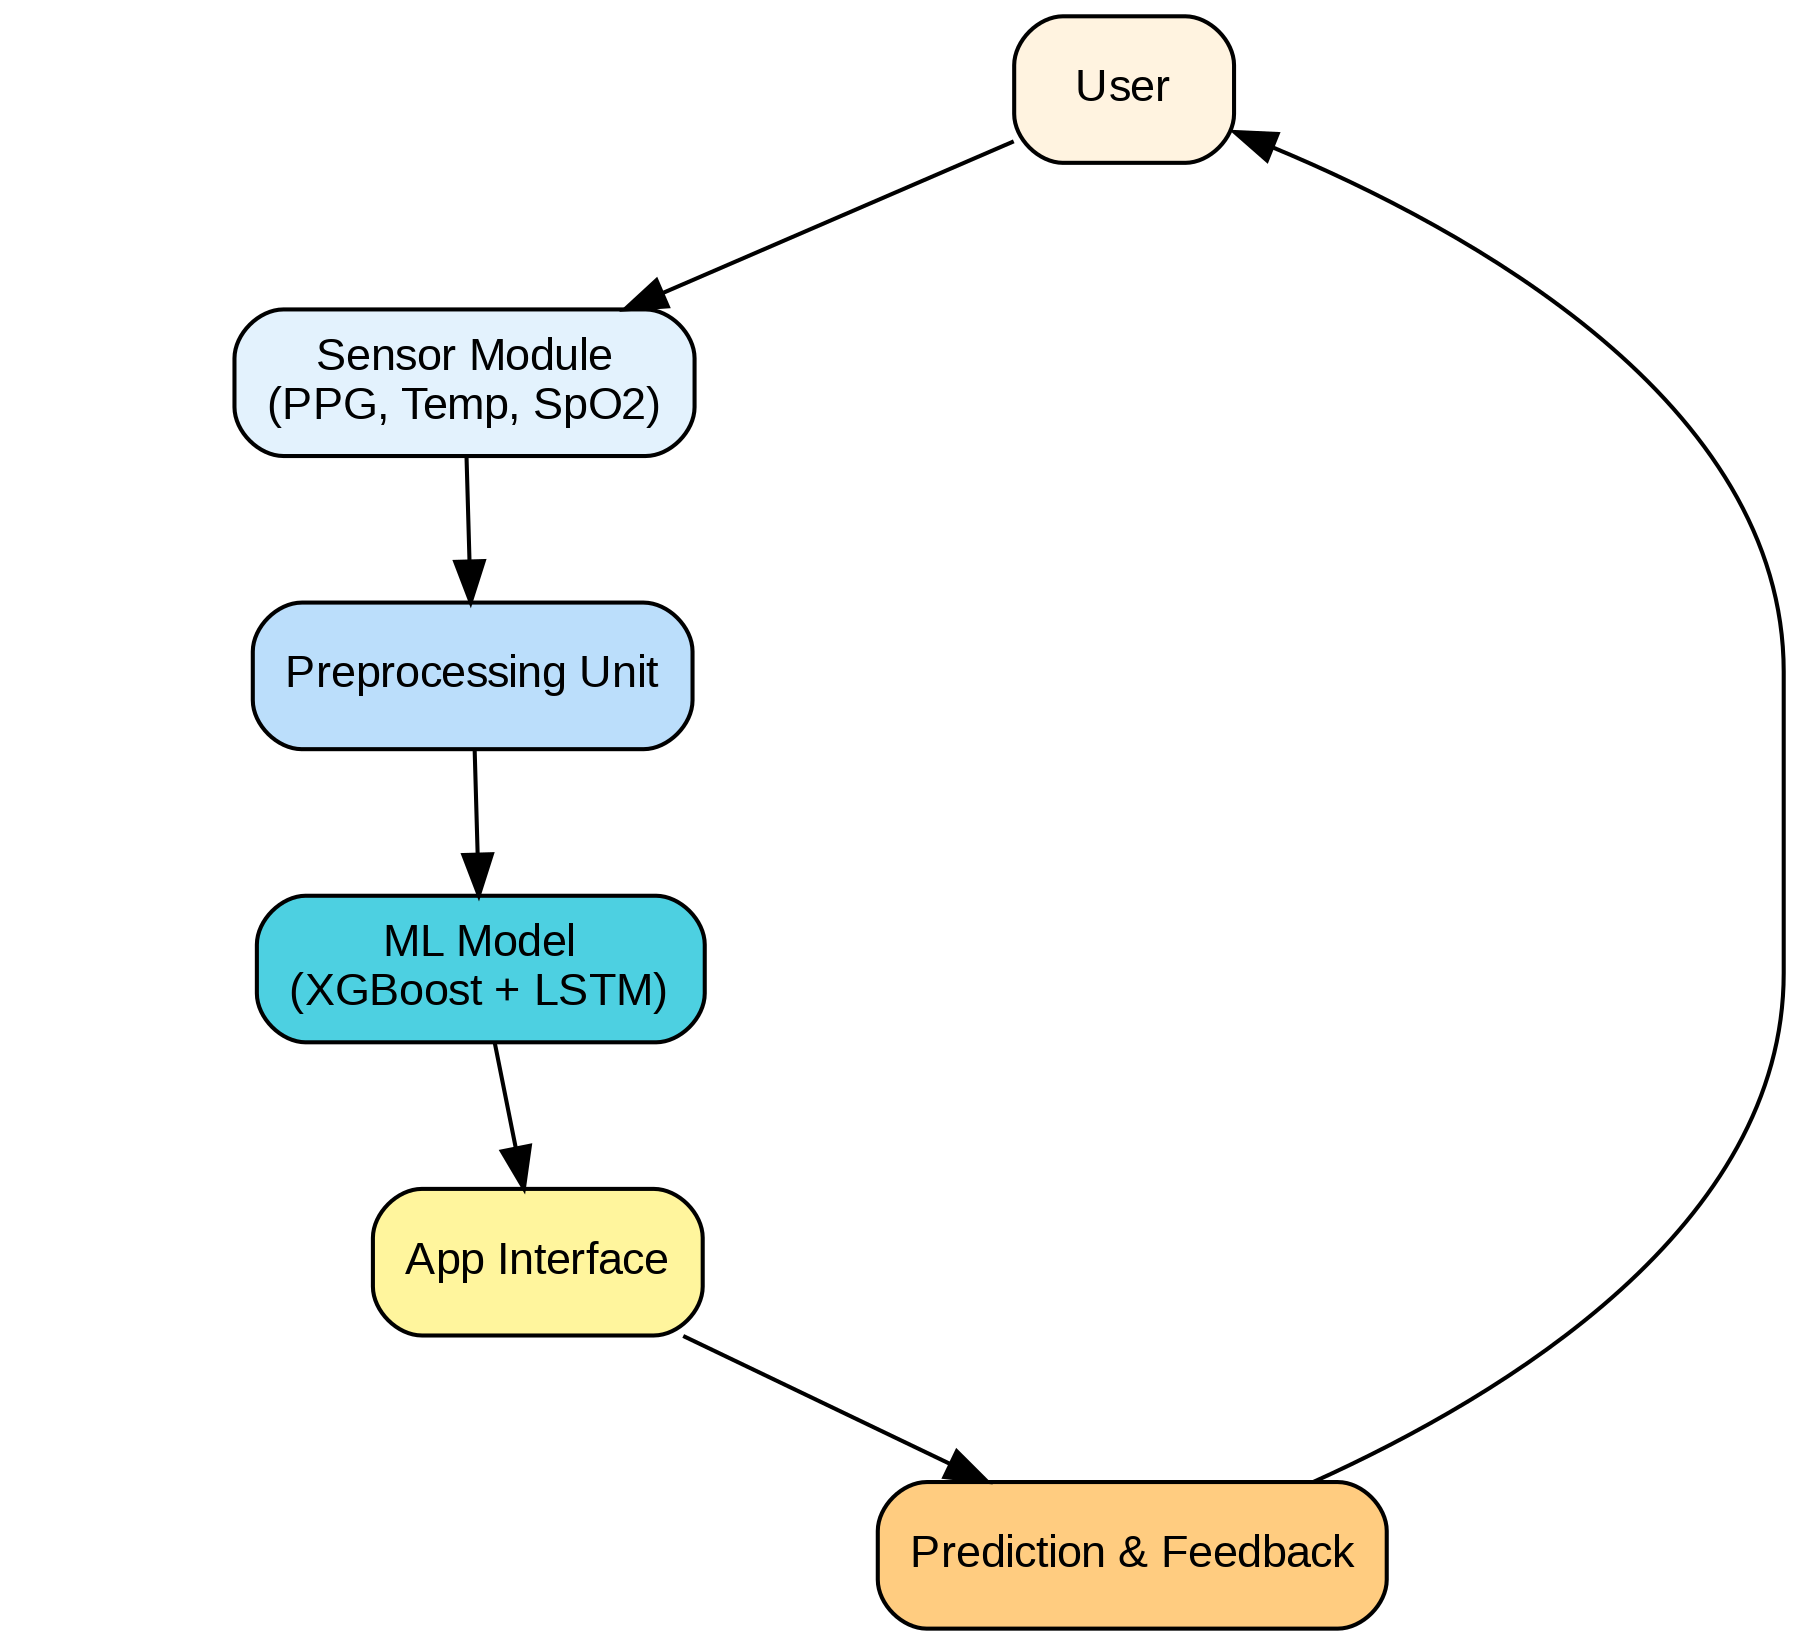

In [ ]:
dfd1 = Digraph('DFD_Level_1_Square', format='png')

dfd1.attr(size='6,6', dpi='300', ratio='1.0', rankdir='TB', nodesep='1.0')
dfd1.attr('node', fontname='Helvetica', shape='box', style='filled,rounded', fontsize='11')

# Nodes
dfd1.node('U', 'User', fillcolor='#FFF3E0')
dfd1.node('S', 'Sensor Module\n(PPG, Temp, SpO2)', fillcolor='#E3F2FD')
dfd1.node('P', 'Preprocessing Unit', fillcolor='#BBDEFB')
dfd1.node('M', 'ML Model\n(XGBoost + LSTM)', fillcolor='#4DD0E1')
dfd1.node('A', 'App Interface', fillcolor='#FFF59D')
dfd1.node('F', 'Prediction & Feedback', fillcolor='#FFCC80')

# Connections
dfd1.edge('U', 'S')
dfd1.edge('S', 'P')
dfd1.edge('P', 'M')
dfd1.edge('M', 'A')
dfd1.edge('A', 'F')
dfd1.edge('F', 'U')

# Render & display
output_path = dfd1.render('dfd_level1_square', format='png', cleanup=False)
Image(output_path)


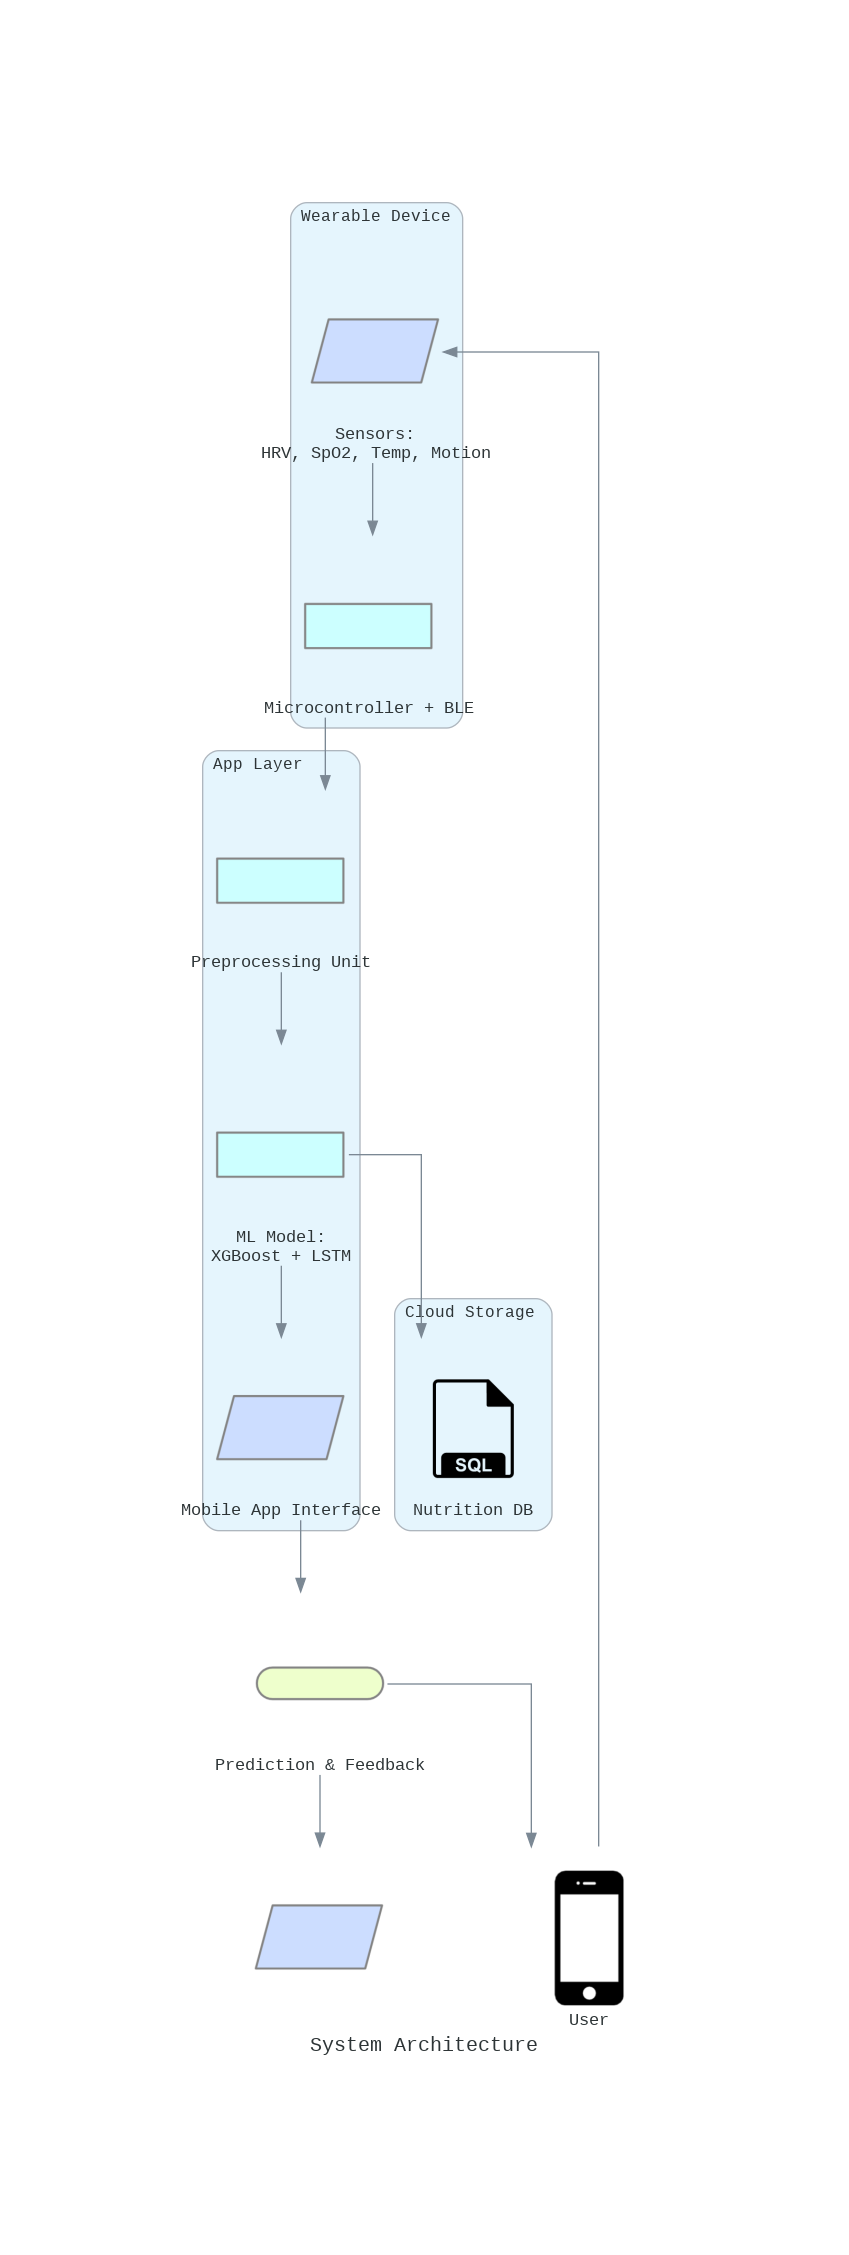

In [ ]:
from diagrams import Diagram, Cluster
from diagrams.generic.device import Mobile
from diagrams.generic.database import SQL
from diagrams.programming.flowchart import Action, InputOutput, StartEnd
from IPython.display import Image

# Create diagram
with Diagram("System Architecture",
             filename="system_architecture_diagram_square",
             direction="TB",  # Top to Bottom
             outformat="png",
             show=False):

    user = Mobile("User")

    with Cluster("Wearable Device"):
        sensor = InputOutput("Sensors:\nHRV, SpO2, Temp, Motion")
        mcu = Action("Microcontroller + BLE")

    with Cluster("App Layer"):
        preproc = Action("Preprocessing Unit")
        model = Action("ML Model:\nXGBoost + LSTM")
        ui = InputOutput("Mobile App Interface")

    with Cluster("Cloud Storage"):
        db = SQL("Nutrition DB")

    result = StartEnd("Prediction & Feedback")

    # Flow: Circular
    user >> sensor >> mcu >> preproc >> model >> ui >> result >> user
    model >> db  # data storage edge

    # Dummy invisible node to enforce square layout
    dummy = InputOutput("")
    result >> dummy

# Show the diagram
Image("system_architecture_diagram_square.png")


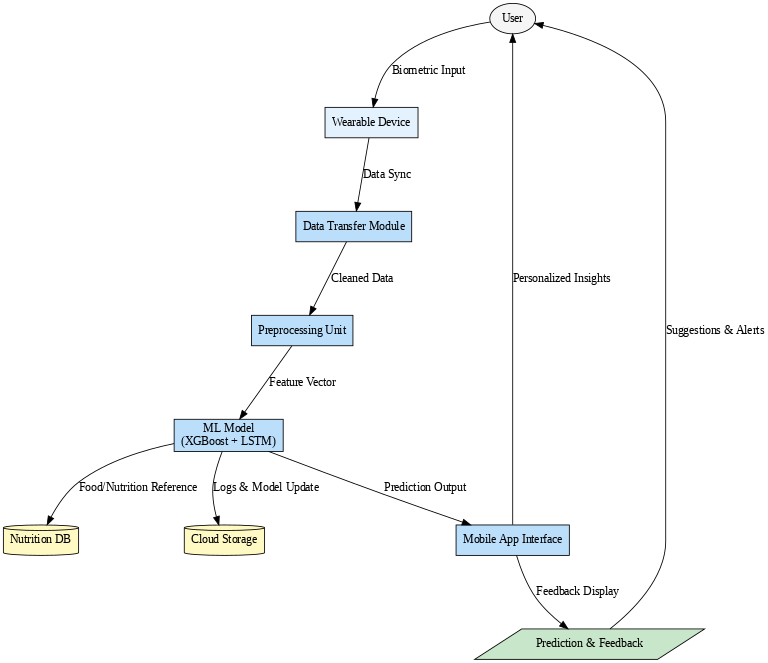

In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

diagram = Digraph('System_Architecture_Final', format='png')
diagram.attr(rankdir='TB', size='8', nodesep='1', ranksep='1', fontname='Helvetica', fontsize='11')

main_style = {'style': 'filled', 'shape': 'box', 'fillcolor': '#E3F2FD'}
process_style = {'style': 'filled', 'shape': 'box', 'fillcolor': '#BBDEFB'}
storage_style = {'style': 'filled', 'shape': 'cylinder', 'fillcolor': '#FFF9C4'}
output_style = {'style': 'filled', 'shape': 'parallelogram', 'fillcolor': '#C8E6C9'}
user_style = {'style': 'filled', 'shape': 'ellipse', 'fillcolor': '#F5F5F5'}

diagram.node('User', 'User', **user_style)
diagram.node('Wearable', 'Wearable Device', **main_style)
diagram.node('Transfer', 'Data Transfer Module', **process_style)
diagram.node('Preprocess', 'Preprocessing Unit', **process_style)
diagram.node('Model', 'ML Model\n(XGBoost + LSTM)', **process_style)
diagram.node('App', 'Mobile App Interface', **process_style)
diagram.node('Feedback', 'Prediction & Feedback', **output_style)
diagram.node('Cloud', 'Cloud Storage', **storage_style)
diagram.node('DB', 'Nutrition DB', **storage_style)

diagram.edge('User', 'Wearable', 'Biometric Input')
diagram.edge('Wearable', 'Transfer', 'Data Sync')
diagram.edge('Transfer', 'Preprocess', 'Cleaned Data')
diagram.edge('Preprocess', 'Model', 'Feature Vector')
diagram.edge('Model', 'App', 'Prediction Output')
diagram.edge('App', 'User', 'Personalized Insights')
diagram.edge('Model', 'Cloud', 'Logs & Model Update')
diagram.edge('Model', 'DB', 'Food/Nutrition Reference')
diagram.edge('App', 'Feedback', 'Feedback Display')
diagram.edge('Feedback', 'User', 'Suggestions & Alerts')

# Render & show image
diagram.render('/content/system_architecture_final', cleanup=False)
display(Image(filename='/content/system_architecture_final.png'))



In [ ]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib


import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# Load the datasets
pima = pd.read_csv('diabetes.csv')
nutrition = pd.read_csv('food_nutrition.csv')

# Select relevant columns from Pima dataset
pima = pima[['Age', 'BMI', 'Glucose', 'Outcome']]  # Essential health data

# Select and rename the carbohydrate column from the Nutrition dataset
nutrition = nutrition[['Description', 'Data.Carbohydrate']]
nutrition.rename(columns={'Description': 'Food', 'Data.Carbohydrate': 'Carbohydrates'}, inplace=True)

# Display first few rows
print("Pima Dataset:")
print(pima.head())

print("\nFood Nutrition Dataset:")
print(nutrition.head())


# Define realistic carb intake ranges based on BMI and glucose levels
def calculate_carb_intake(age, bmi, glucose):
    if glucose < 100:  # Normal glucose
        return np.random.randint(150, 300)  # Normal diet
    elif glucose < 126:  # Pre-diabetic
        return np.random.randint(100, 200)  # Controlled diet
    else:  # Diabetic
        return np.random.randint(50, 150)  # Restricted diet

# Apply function to generate synthetic carb intake data
pima['Daily_Carb_Intake'] = pima.apply(lambda row: calculate_carb_intake(row['Age'], row['BMI'], row['Glucose']), axis=1)

# Display dataset
print(pima.head())


# Define features (X) and target (y)
features = pima[['Age', 'BMI', 'Glucose']]  # Input variables
labels = pima['Daily_Carb_Intake']  # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Print dataset sizes
print("Training Set Size:", len(X_train))
print("Testing Set Size:", len(X_test))


# Initialize the scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test_scaled)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


!pip install --upgrade scikit-learn xgboost


from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the model
hgb_model = HistGradientBoostingRegressor()

# Define hyperparameters
param_grid = {
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Perform Grid Search
grid_search = GridSearchCV(estimator=hgb_model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Get best parameters
print("Best Parameters:", grid_search.best_params_)

# Train the best model
best_model = grid_search.best_estimator_


import joblib

# Save the model
joblib.dump(best_model, 'carb_prediction_model.pkl')

# Load the model later
# loaded_model = joblib.load('carb_prediction_model.pkl')


# Define a new user profile
new_user = {
    'Age': 19,
    'BMI': 19,
    'Glucose': 110
}

# Convert to DataFrame
new_user_df = pd.DataFrame([new_user])

# Scale the input before making predictions
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = best_model.predict(new_user_df_scaled)
print(f"Updated Predicted Daily Carb Intake: {carb_prediction[0]:.2f} grams")


import numpy as np

# Define a function to calculate BMI from height & weight
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return weight / (height_m ** 2)

# Define realistic ranges for weight & height based on age
np.random.seed(42)
pima['Weight'] = np.random.randint(50, 100, size=len(pima))  # Random weights (50-100 kg)
pima['Height'] = np.random.randint(150, 190, size=len(pima))  # Random heights (150-190 cm)

# Calculate BMI using the new weight & height columns
pima['BMI'] = pima.apply(lambda row: calculate_bmi(row['Weight'], row['Height']), axis=1)

# Add random Activity Levels (1 = Sedentary, 2 = Lightly Active, 3 = Active, 4 = Very Active)
pima['Activity_Level'] = np.random.randint(1, 5, size=len(pima))

# Display dataset
print(pima.head())


# Define realistic carbohydrate intake based on weight, activity, and glucose levels
def calculate_carb_intake(age, weight, bmi, activity, glucose):
    base_carb = 130  # Minimum daily carb requirement

    # Adjust based on BMI
    if bmi < 18.5:  # Underweight
        base_carb += 50
    elif bmi > 25:  # Overweight
        base_carb -= 30

    # Adjust based on glucose levels
    if glucose < 100:  # Normal glucose
        base_carb += 50
    elif glucose < 126:  # Pre-diabetic
        base_carb -= 20
    else:  # Diabetic
        base_carb -= 50

    # Adjust based on Activity Level
    if activity == 1:  # Sedentary
        base_carb -= 30
    elif activity == 3 or activity == 4:  # Active or Very Active
        base_carb += 50

    return max(50, min(base_carb, 400))  # Ensure values stay realistic

# Apply function to generate accurate carb intake data
pima['Daily_Carb_Intake'] = pima.apply(lambda row: calculate_carb_intake(
    row['Age'], row['Weight'], row['BMI'], row['Activity_Level'], row['Glucose']), axis=1)

# Display dataset
print(pima.head())


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Define updated features and target
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose']]
labels = pima['Daily_Carb_Intake']

# Split dataset into training & testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model using XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = xgb_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


# Define a new user profile
new_user = {
    'Age': 19,
    'Weight': 69,  # 70 kg
    'Height': 172,  # 175 cm
    'BMI': calculate_bmi(69, 172),  # Calculate BMI
    'Activity_Level': 3,  # Active
    'Glucose': 110  # Normal glucose
}

# Convert to DataFrame
new_user_df = pd.DataFrame([new_user])

# Scale the input
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = xgb_model.predict(new_user_df_scaled)
print(f"Updated Predicted Daily Carb Intake: {carb_prediction[0]:.2f} grams")


# Function to calculate BMI
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return weight / (height_m ** 2)

# Function to calculate BMR (Mifflin-St Jeor Equation for Males)
def calculate_bmr(weight, height, age):
    return (10 * weight) + (6.25 * height) - (5 * age) + 5  # (For females: Subtract 161 instead of adding 5)

# Activity level multiplier for TDEE
activity_multiplier = {1: 1.2, 2: 1.375, 3: 1.55, 4: 1.725}

# Function to calculate TDEE (Total Daily Energy Expenditure)
def calculate_tdee(bmr, activity_level):
    return bmr * activity_multiplier.get(activity_level, 1.2)  # Default to sedentary if unknown

# Apply functions to dataset
pima['BMI'] = pima.apply(lambda row: calculate_bmi(row['Weight'], row['Height']), axis=1)
pima['BMR'] = pima.apply(lambda row: calculate_bmr(row['Weight'], row['Height'], row['Age']), axis=1)
pima['TDEE'] = pima.apply(lambda row: calculate_tdee(row['BMR'], row['Activity_Level']), axis=1)

# Display updated dataset
print(pima.head())


# Define updated features and target
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose', 'BMR', 'TDEE']]
labels = pima['Daily_Carb_Intake']

# Train the model using the same method as before...


# Function to calculate BMI
def calculate_bmi(weight, height):
    height_m = height / 100  # Convert cm to meters
    return round(weight / (height_m ** 2), 2)  # Rounded for accuracy

# Function to calculate BMR (Mifflin-St Jeor Equation for Males)
def calculate_bmr(weight, height, age, gender='male'):
    if gender == 'male':
        return round((10 * weight) + (6.25 * height) - (5 * age) + 5, 2)  # BMR formula for males
    else:
        return round((10 * weight) + (6.25 * height) - (5 * age) - 161, 2)  # BMR formula for females

# Activity level multipliers for TDEE calculation
activity_multiplier = {
    1: 1.2,    # Sedentary (little to no exercise)
    2: 1.375,  # Lightly Active (1-3 days/week)
    3: 1.55,   # Moderately Active (3-5 days/week)
    4: 1.725   # Very Active (6-7 days/week)
}

# Function to calculate TDEE (Total Daily Energy Expenditure)
def calculate_tdee(bmr, activity_level):
    return round(bmr * activity_multiplier.get(activity_level, 1.2), 2)  # Default to sedentary if unknown

# Define updated features and target variable
features = pima[['Age', 'Weight', 'Height', 'BMI', 'Activity_Level', 'Glucose', 'BMR', 'TDEE']]
labels = pima['Daily_Carb_Intake']

# Split the dataset again
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Apply scaling again
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the updated model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

print("✅ Model retrained successfully with BMR & TDEE!")


# User Inputs
age = int(input("Enter Age (years): "))
weight = float(input("Enter Weight (kg): "))
height = float(input("Enter Height (cm): "))
activity_level = int(input("Enter Activity Level (1=Sedentary, 2=Light, 3=Active, 4=Very Active): "))
glucose = float(input("Enter Glucose Level (mg/dL): "))
gender = input("Enter Gender (male/female): ").strip().lower()  # Ensure input is lowercase

# Auto-calculate BMI, BMR, and TDEE
bmi = calculate_bmi(weight, height)
bmr = calculate_bmr(weight, height, age, gender)
tdee = calculate_tdee(bmr, activity_level)

# Display Calculated Values
print("\n===== Health Metrics =====")
print(f"BMI: {bmi}")
print(f"BMR: {bmr} kcal/day")
print(f"TDEE: {tdee} kcal/day")


import pandas as pd

# Prepare user data for prediction
new_user_df = pd.DataFrame([{
    'Age': age,
    'Weight': weight,
    'Height': height,
    'BMI': bmi,
    'Activity_Level': activity_level,
    'Glucose': glucose,
    'BMR': bmr,
    'TDEE': tdee
}])

print("\n🔷 User Data for Prediction:")
print(new_user_df)


# Ensure new user input has the same feature order as training data
new_user_df = pd.DataFrame([{
    'Age': age,
    'Weight': weight,
    'Height': height,
    'BMI': bmi,
    'Activity_Level': activity_level,
    'Glucose': glucose,
    'BMR': bmr,
    'TDEE': tdee
}])[features.columns]  # Reorder columns to match training data

# Scale input before prediction
new_user_df_scaled = scaler.transform(new_user_df)

# Predict carbohydrate intake
carb_prediction = xgb_model.predict(new_user_df_scaled)
print(f"\n🔷 Predicted Daily Carbohydrate Intake: {carb_prediction[0]:.2f} grams")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Define true and predicted labels (categorizing carb intake levels)
true_classes = np.digitize(y_test, bins=[100, 200, 300, 400])
pred_classes = np.digitize(xgb_model.predict(X_test_scaled), bins=[100, 200, 300, 400])






Pima Dataset:
   Age   BMI  Glucose  Outcome
0   50  33.6      148        1
1   31  26.6       85        0
2   32  23.3      183        1
3   21  28.1       89        0
4   33  43.1      137        1

Food Nutrition Dataset:
                       Food  Carbohydrates
0          BUTTER,WITH SALT           0.06
1  BUTTER,WHIPPED,WITH SALT           0.06
2      BUTTER OIL,ANHYDROUS           0.00
3               CHEESE,BLUE           2.34
4              CHEESE,BRICK           2.79
   Age   BMI  Glucose  Outcome  Daily_Carb_Intake
0   50  33.6      148        1                 92
1   31  26.6       85        0                236
2   32  23.3      183        1                119
3   21  28.1       89        0                195
4   33  43.1      137        1                 92
Training Set Size: 614
Testing Set Size: 154
Mean Squared Error: 1405.40
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}
Updated Predicted Daily Carb Intake: 147.19 grams
   Age        BMI  G